In [1]:
import optuna
import numpy as np
import pandas as pd
import yfinance as yf
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import CallbackList
import gymnasium as gym
from gymnasium import spaces
import gc
import optuna
import numpy as np
from stable_baselines3 import PPO
from wandb.integration.sb3 import WandbCallback
import wandb
from alibi_detect.od import IForest
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import torch

d:\dev\dev python\OrionTrader\.venv\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
d:\dev\dev python\OrionTrader\.venv\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` 

In [2]:
TRAINING_STEPS = 1_000_000
TENSORBOARD_LOGDIR = "./logs/optuna_forex"
MODEL_DIR = "tmp_models"

In [3]:
# Téléchargement des données
df = yf.download("EURUSD=X", start="2020-01-01", end="2025-10-01", interval="1d")

# Gestion du MultiIndex éventuel
if isinstance(df.columns, pd.MultiIndex):
    # Aplatir et retirer le nom du ticker s’il est présent
    df.columns = [col[0].lower() for col in df.columns]
else:
    df.columns = [col.lower() for col in df.columns]

# Création des features
df["price_change"] = df["close"].pct_change().rolling(window=3).mean().fillna(0)
if "volume" in df.columns:
    df["volume_change"] = df["volume"].pct_change().rolling(window=3).mean().fillna(0)
else:
    df["volume_change"] = 0  # parfois volume est absent sur le Forex

df["close_norm"] = (df["close"] - df["close"].mean()) / df["close"].std()

# Nettoyage
df = df.dropna().reset_index(drop=True)

print("✅ Colonnes finales :", df.columns.tolist())
df.head()


C:\Users\Aurelien\AppData\Local\Temp\ipykernel_19060\1531566758.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("EURUSD=X", start="2020-01-01", end="2025-10-01", interval="1d")
[*********************100%***********************]  1 of 1 completed

✅ Colonnes finales : ['close', 'high', 'low', 'open', 'volume', 'price_change', 'volume_change', 'close_norm']


,close,high,low,open,volume,price_change,volume_change,close_norm
0,1.122083,1.122838,1.115947,1.122083,0,0.000000,0.0,0.211345
1,1.122083,1.122712,1.116682,1.121894,0,0.000000,0.0,0.211345
2,1.117144,1.118068,1.112570,1.117081,0,0.000000,0.0,0.125514
3,1.116196,1.120825,1.115810,1.116246,0,-0.001750,0.0,0.109044
4,1.119799,1.119946,1.113487,1.119583,0,-0.000674,0.0,0.171668


In [4]:
class ForexEnv(gym.Env):
    """
    Environnement Forex unifié, compatible avec MetaTrader et données locales.
    - Reward basée sur Sharpe ratio local
    - Pénalités de drawdown et volatilité
    - Gestion automatique des colonnes et des coûts de transaction
    """
    def __init__(
        self,
        df,
        transaction_cost=0.0001,
        max_leverage=1.0,
        clip_range=1.0,
        reward_window=50,
        risk_penalty=0.001,
        vol_penalty=0.0005
    ):
        super(ForexEnv, self).__init__()
        self.df = df.reset_index(drop=True)

        # ✅ Harmonisation des noms de colonnes (pour MT5 ou CSV)
        self.df.columns = [col.lower() for col in self.df.columns]
        if 'close' not in self.df.columns:
            raise KeyError("La colonne 'close' est absente du DataFrame fourni.")

        # Paramètres
        self.transaction_cost = transaction_cost
        self.max_leverage = max_leverage
        self.clip_range = clip_range
        self.reward_window = reward_window
        self.risk_penalty = risk_penalty
        self.vol_penalty = vol_penalty

        # État interne
        self.current_step = 0
        self.balance = 10000.0
        self.initial_balance = self.balance
        self.max_balance = self.balance
        self.position = 0  # 0 neutre, 1 long, -1 short
        self.entry_price = 0.0
        self.pnl_history = []
        self.recent_rewards = []

        # Espaces d'action et d'observation
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(2,), dtype=np.float32)

    # -------------------------------------------------------
    # 🔹 Réinitialisation
    # -------------------------------------------------------
    def reset(self, **kwargs):
        self.current_step = 0
        self.balance = self.initial_balance
        self.max_balance = self.balance
        self.position = 0
        self.entry_price = 0.0
        self.pnl_history.clear()
        self.recent_rewards.clear()
        return self._next_obs(), {}

    # -------------------------------------------------------
    # 🔹 Observation suivante
    # -------------------------------------------------------
    def _next_obs(self):
        price = float(self.df.loc[self.current_step, "close"])
        delta = (
            float(self.df.loc[self.current_step, "close"] - self.df.loc[self.current_step - 1, "close"])
            if self.current_step > 0 else 0.0
        )
        return np.array([price, delta], dtype=np.float32)

    # -------------------------------------------------------
    # 🔹 Step principal
    # -------------------------------------------------------
    def step(self, action):
        prev_price = float(self.df.loc[self.current_step, "close"])
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1
        truncated = False
        price = float(self.df.loc[self.current_step, "close"])
        delta = price - prev_price

        # --- PnL relatif ---
        rel_return = delta / prev_price
        pnl = self.position * rel_return * self.balance * self.max_leverage

        # --- Coût de transaction ---
        cost = 0.0
        if (self.position == 1 and action == 2) or (self.position == -1 and action == 1):
            cost = self.transaction_cost * abs(self.balance)

        # --- Mise à jour de la position ---
        if action == 1:
            self.position = 1
        elif action == 2:
            self.position = -1
        # sinon on conserve la position

        # --- Mise à jour du solde ---
        self.balance += pnl - cost
        self.balance = max(self.balance, 0)
        self.max_balance = max(self.max_balance, self.balance)
        drawdown = (self.max_balance - self.balance) / max(self.max_balance, 1)

        # --- Historique pour reward ---
        normalized_pnl = pnl / self.initial_balance
        self.pnl_history.append(normalized_pnl)
        if len(self.pnl_history) > self.reward_window:
            self.pnl_history.pop(0)

        # --- Reward : Sharpe ratio local ---
        mean_pnl = np.mean(self.pnl_history)
        std_pnl = np.std(self.pnl_history) + 1e-8
        sharpe_local = mean_pnl / std_pnl if std_pnl > 0 else 0.0

        # --- Reward finale ---
        reward = sharpe_local - self.risk_penalty * drawdown

        self.recent_rewards.append(reward)
        if len(self.recent_rewards) > self.reward_window:
            self.recent_rewards.pop(0)
            volatility = np.std(self.recent_rewards)
            reward -= self.vol_penalty * volatility

        reward = np.clip(reward, -self.clip_range, self.clip_range)

        # --- Stop si drawdown trop fort ou balance trop basse ---
        if drawdown > 0.3 or self.balance <= 100:
            terminated = True

        obs = np.array([price, delta], dtype=np.float32)
        info = {
            "balance": self.balance,
            "position": self.position,
            "pnl": pnl,
            "drawdown": drawdown,
        }
        return obs, reward, terminated, truncated, info

    # -------------------------------------------------------
    # 🔹 Récupération info (pour MT5, debug, etc.)
    # -------------------------------------------------------
    def get_info(self):
        return {
            "balance": self.balance,
            "position": self.position,
            "current_price": float(self.df.loc[self.current_step, "close"]),
        }



In [5]:
import numpy as np
import torch
import random
import optuna
import yfinance as yf
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback, CallbackList

def make_env(df, seed=None):
    def _init():
        env = ForexEnv(df)
        try:
            env.reset(seed=seed)
        except TypeError:
            pass
        return Monitor(env)
    return _init


def optimize_ppo(trial):
    seed = 1000 + trial.number
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    learning_rate = trial.suggest_float("learning_rate", 1e-5, 3e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    n_steps = max(batch_size, trial.suggest_categorical("n_steps", [1024, 2048, 4096]))
    gamma = trial.suggest_float("gamma", 0.90, 0.9999)
    clip_range = trial.suggest_float("clip_range", 0.1, 0.3)
    gae_lambda = trial.suggest_float("gae_lambda", 0.9, 0.99)
    ent_coef = trial.suggest_float("ent_coef", 1e-5, 0.01, log=True)
    vf_coef = trial.suggest_float("vf_coef", 0.4, 0.8)
    max_grad_norm = trial.suggest_float("max_grad_norm", 0.3, 0.8)

    train_env = DummyVecEnv([make_env(df, seed)])
    eval_env = DummyVecEnv([make_env(df, seed + 9999)])

    model = PPO(
        "MlpPolicy",
        train_env,
        learning_rate=learning_rate,
        n_steps=n_steps,
        batch_size=batch_size,
        gamma=gamma,
        ent_coef=ent_coef,
        vf_coef=vf_coef,
        clip_range=clip_range,
        gae_lambda=gae_lambda,
        max_grad_norm=max_grad_norm,
        verbose=0,
    )

    callbacks = CallbackList([
        NaNStopCallback(),
        EarlyStoppingCallback(check_freq=5000, min_improvement=0.02),
    ])

    model.learn(total_timesteps=TRAINING_STEPS, callback=callbacks)

    mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=False)

    trial.set_user_attr("mean_reward", float(mean_reward))
    trial.set_user_attr("std_reward", float(std_reward))
    return float(mean_reward - std_reward * 0.1)


class NaNStopCallback(BaseCallback):
    def _on_step(self):
        for param in self.model.policy.parameters():
            if torch.isnan(param).any():
                print("❌ NaN détecté — arrêt de l'entraînement.")
                return False
        return True

class EarlyStoppingCallback(BaseCallback):
    def __init__(self, check_freq=5000, min_improvement=0.02, lookback=5):
        super().__init__()
        self.check_freq = check_freq
        self.min_improvement = min_improvement
        self.lookback = lookback
        self.rewards = []

    def _on_step(self):
        if self.n_calls % self.check_freq == 0 and len(self.model.ep_info_buffer) > 0:
            current_reward = np.mean([ep_info["r"] for ep_info in self.model.ep_info_buffer])
            self.rewards.append(current_reward)
            if len(self.rewards) > self.lookback:
                old_mean = np.mean(self.rewards[-self.lookback-1:-1])
                new_mean = np.mean(self.rewards[-self.lookback:])
                if (new_mean - old_mean) < self.min_improvement:
                    print(f"⚠️ Early stopping triggered: reward stagnante ({new_mean:.2f})")
                    return False
        return True

class EquityVisualizerCallback(BaseCallback):
    """
    Collecte equity, prices and positions during training.
    Use plot_results() after training to visualize.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.equity = []
        self.prices = []
        self.positions = []

    def _on_step(self) -> bool:
        # infos available via self.locals["infos"] for VecEnv
        infos = self.locals.get("infos")
        if infos:
            info = infos[0] if isinstance(infos, (list, tuple)) else infos
            if isinstance(info, dict):
                bal = info.get("balance")
                pos = info.get("position")
                close = info.get("close")
                if bal is not None:
                    self.equity.append(bal)
                if pos is not None:
                    self.positions.append(pos)
                if close is not None:
                    self.prices.append(close)
        return True

    def plot_results(self):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1])

        ax1.plot(self.equity, color="blue")
        ax1.set_title("💰 Évolution de la balance")
        ax1.set_xlabel("Étapes")
        ax1.set_ylabel("Balance")
        ax1.grid(True)

        ax2.plot(self.prices, color="gray", alpha=0.6, label="Prix")
        for i in range(1, len(self.positions)):
            if self.positions[i] == 1:
                ax2.axvspan(i-1, i, color="green", alpha=0.3)
            elif self.positions[i] == -1:
                ax2.axvspan(i-1, i, color="red", alpha=0.3)

        ax2.set_title("📈 Prix et positions")
        ax2.set_xlabel("Étapes")
        ax2.grid(True)
        plt.tight_layout()
        plt.show()

In [6]:
import os
import optuna
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from datetime import datetime

# === PARAMÈTRES GLOBAUX ===
RESULTS_DIR = "optuna_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# === CRÉATION & LANCEMENT DE L'ÉTUDE ===
study_name = f"ppo_forex_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
storage_name = f"sqlite:///{RESULTS_DIR}/{study_name}.db"  # base de stockage locale
study = optuna.create_study(direction="maximize", study_name=study_name, storage=storage_name)

print("🚀 Début de l'optimisation des hyperparamètres...")
study.optimize(optimize_ppo, n_trials=20, gc_after_trial=True)

# === SÉLECTION DU MEILLEUR TRIAL ===
best_trial = max(
    study.get_trials(deepcopy=False),
    key=lambda t: t.value if t.value is not None else float('-inf')
)

print("\n✅ Meilleur essai trouvé :")
print(f"  • Reward : {best_trial.value:.4f}")
print(f"  • Paramètres : {best_trial.params}")

[I 2025-11-02 02:55:50,705] A new study created in RDB with name: ppo_forex_20251102_025546


🚀 Début de l'optimisation des hyperparamètres...
⚠️ Early stopping triggered: reward stagnante (-14.46)


[I 2025-11-02 02:56:48,447] Trial 0 finished with value: -10.677843667210444 and parameters: {'learning_rate': 0.00020652819510923125, 'batch_size': 64, 'n_steps': 2048, 'gamma': 0.9264411405034597, 'clip_range': 0.1082408133662835, 'gae_lambda': 0.9815995815833085, 'ent_coef': 0.0012463484286706428, 'vf_coef': 0.40777614691144504, 'max_grad_norm': 0.31798074632955037}. Best is trial 0 with value: -10.677843667210444.


⚠️ Early stopping triggered: reward stagnante (10.29)


[I 2025-11-02 02:57:50,233] Trial 1 finished with value: -6.923888621786272 and parameters: {'learning_rate': 0.00018477775418029806, 'batch_size': 128, 'n_steps': 1024, 'gamma': 0.9435321526809903, 'clip_range': 0.18833911642742412, 'gae_lambda': 0.9616359951848271, 'ent_coef': 0.007706021423052238, 'vf_coef': 0.5404356746653478, 'max_grad_norm': 0.6103178907087377}. Best is trial 1 with value: -6.923888621786272.


...

⚠️ Early stopping triggered: reward stagnante (13.38)


[I 2025-11-02 03:15:14,412] Trial 18 finished with value: -8.169381541923997 and parameters: {'learning_rate': 2.7826346464290957e-05, 'batch_size': 64, 'n_steps': 1024, 'gamma': 0.9166505964896481, 'clip_range': 0.2735961703021325, 'gae_lambda': 0.9478801345531154, 'ent_coef': 9.79772567978223e-05, 'vf_coef': 0.4931866047102857, 'max_grad_norm': 0.38417192101337316}. Best is trial 16 with value: 15.699212445422441.


⚠️ Early stopping triggered: reward stagnante (1.62)


[I 2025-11-02 03:16:18,630] Trial 19 finished with value: -13.977406585565626 and parameters: {'learning_rate': 0.0001308218098018567, 'batch_size': 64, 'n_steps': 4096, 'gamma': 0.9406976960405373, 'clip_range': 0.21462904577590147, 'gae_lambda': 0.9619383907874187, 'ent_coef': 0.00044742893658093, 'vf_coef': 0.40098396311174245, 'max_grad_norm': 0.3898338946182147}. Best is trial 16 with value: 15.699212445422441.



✅ Meilleur essai trouvé :
  • Reward : 15.6992
  • Paramètres : {'learning_rate': 2.863473616126334e-05, 'batch_size': 64, 'n_steps': 1024, 'gamma': 0.9025456221581111, 'clip_range': 0.26606450716014723, 'gae_lambda': 0.9708639305339158, 'ent_coef': 0.0006900758943777371, 'vf_coef': 0.5137721129947794, 'max_grad_norm': 0.5461233826106195}


In [7]:
# === PARAMÈTRES GLOBAUX ===
RESULTS_DIR = "optuna_results"
MODELS_DIR = "models"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# === ÉTUDE OPTUNA (ton bloc existant) ===
# (on suppose ici que best_trial est déjà défini)
print("\n✅ Meilleur essai trouvé :")
print(f"  • Reward : {best_trial.value:.4f}")
print(f"  • Paramètres : {best_trial.params}")

# === CALLBACKS PERSONNALISÉS ===
# (tes classes EquityVisualizerCallback, EarlyStoppingCallback et WandbCallback doivent être importées ici)

def train_with_monitoring(model, env, total_timesteps, seed=None):
    """Entraînement complet avec equity curve + early stopping + WandB"""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
        try:
            env.action_space.seed(seed)
        except Exception:
            pass

    # Callbacks
    equity_viz = EquityVisualizerCallback()
    early_stop = EarlyStoppingCallback(check_freq=2000, min_improvement=0.01)
    wandb_cb = WandbCallback(gradient_save_freq=200, model_save_path=MODELS_DIR)

    # Entraînement
    model.learn(
        total_timesteps=total_timesteps,
        callback=[equity_viz, early_stop, wandb_cb],
    )

    print("\n📈 Traçage de l'equity curve et des positions...")
    equity_viz.plot_results()

    print("\n🎯 Évaluation déterministe du modèle final...")
    mean_reward, std_reward = evaluate_policy(
        model, env, n_eval_episodes=5, deterministic=True
    )
    print(f"Reward moyenne: {mean_reward:.2f} ± {std_reward:.2f}")

    return model


def create_single_env(seed=None):
    """Crée un environnement vectorisé unique et vérifié"""
    env = ForexEnv(df)
    if seed is not None:
        try:
            env.reset(seed=seed)
        except TypeError:
            pass
        try:
            env.action_space.seed(seed)
        except Exception:
            pass

    env = Monitor(env)
    vec_env = DummyVecEnv([lambda: env])

    assert len(vec_env.envs) == 1, "DummyVecEnv doit contenir exactement un environnement"
    assert hasattr(vec_env.envs[0].unwrapped, "balance"), "L'environnement doit avoir un attribut 'balance'"

    return vec_env


✅ Meilleur essai trouvé :
  • Reward : 15.6992
  • Paramètres : {'learning_rate': 2.863473616126334e-05, 'batch_size': 64, 'n_steps': 1024, 'gamma': 0.9025456221581111, 'clip_range': 0.26606450716014723, 'gae_lambda': 0.9708639305339158, 'ent_coef': 0.0006900758943777371, 'vf_coef': 0.5137721129947794, 'max_grad_norm': 0.5461233826106195}


Using cpu device
Logging to ./logs/final_training\PPO_1
-----------------------------
| time/              |      |
|    fps             | 833  |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.38e+03     |
|    ep_rew_mean          | -50.4        |
| time/                   |              |
|    fps                  | 725          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0001389184 |
|    clip_fraction        | 0            |
|    clip_range           | 0.266        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -0.000299    |
|    learning_rate        | 2.86e-05     |
|    loss                 | 0.531        |
|  

C:\Users\Aurelien\AppData\Local\Temp\ipykernel_19060\1348510033.py:150: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Aurelien\AppData\Local\Temp\ipykernel_19060\1348510033.py:150: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\dev\dev python\OrionTrader\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\dev\dev python\OrionTrader\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


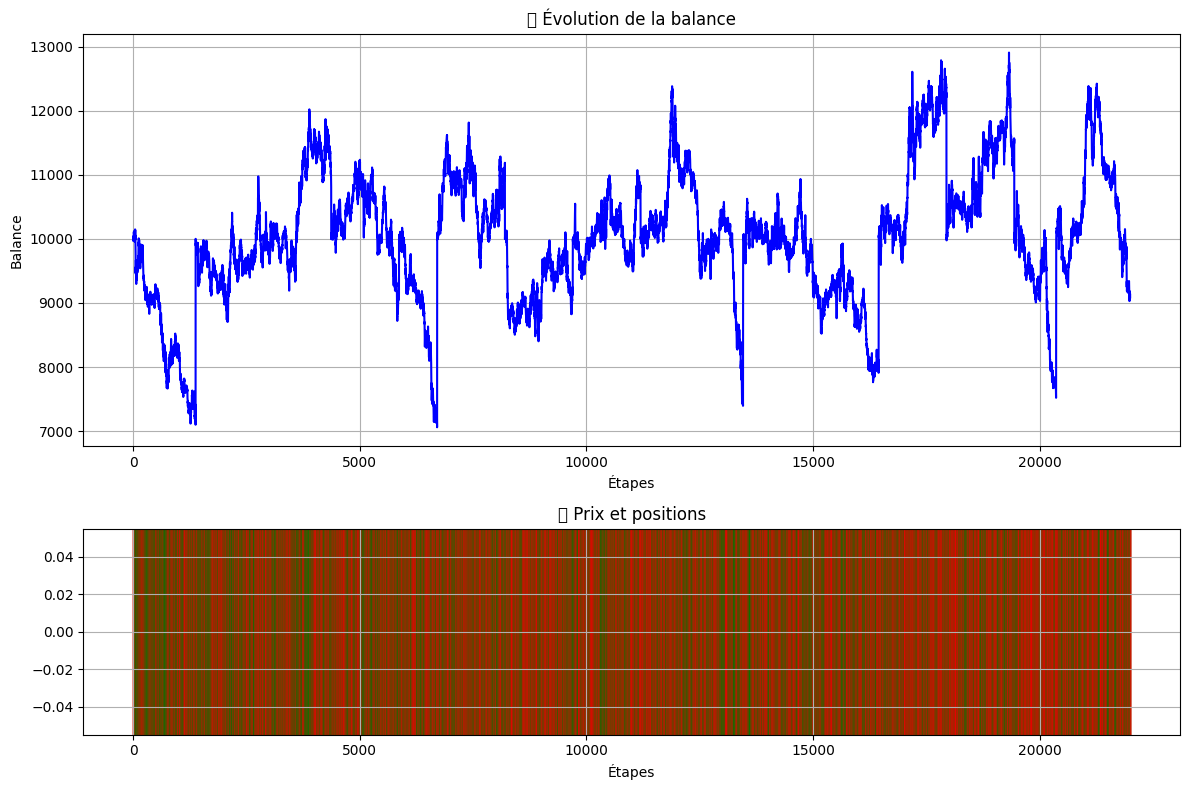


🎯 Évaluation déterministe du modèle final...
Reward moyenne: 6.01 ± 0.00

💾 Modèle sauvegardé : models\best_ppo_forex.zip


In [8]:
SEED = 42
best_params = best_trial.params
env = create_single_env(seed=SEED)

wandb.init(
    mode="offline",
    project="forex-ppo-hallucination",
    config={**best_params, "seed": SEED},
)

best_model = PPO("MlpPolicy", env, **best_params, verbose=1, tensorboard_log="./logs/final_training")
best_model = train_with_monitoring(best_model, env, total_timesteps=500_000, seed=SEED)

# === SAUVEGARDE FINALE ===
model_path = os.path.join(MODELS_DIR, f"best_ppo_forex.zip")
best_model.save(model_path)
wandb.save(model_path)

print(f"\n💾 Modèle sauvegardé : {model_path}")

wandb.finish()
env.close()

In [9]:
def detect_hallucinations(model, env, n_steps=5000, threshold=0.05, plot=True):
    """
    Détecte les comportements incohérents (hallucinations) d’un modèle RL.
    Utilise un IsolationForest sur les séquences d’actions.
    """
    print("\n🔍 Analyse du comportement de la politique sur", n_steps, "pas...")

    obs = env.reset()
    if isinstance(obs, tuple):  # Compatibilité gymnasium
        obs = obs[0]

    actions, rewards = [], []

    for _ in range(n_steps):
        action, _ = model.predict(obs, deterministic=False)
        obs, reward, done, truncated, info = env.step(action) if len(env.step(action)) == 5 else (*env.step(action), False)
        actions.append(action.flatten())
        rewards.append(np.mean(reward))

        # Gestion de fin d'épisode
        if done or truncated:
            obs = env.reset()
            if isinstance(obs, tuple):
                obs = obs[0]

    actions = np.array(actions)
    rewards = np.array(rewards)

    # === Isolation Forest sur les actions ===
    od = IForest(threshold=threshold)
    od.fit(actions)
    preds = od.predict(actions)

    anomaly_ratio = preds["data"]["is_outlier"].mean()
    print(f"⚠️ Anomaly ratio (hallucination risk): {anomaly_ratio:.2%}")

    # === Analyse de stabilité ===
    action_std = np.std(actions, axis=0)
    reward_var = np.var(rewards)
    print(f"📊 Action std: {action_std.mean():.4f} | Reward variance: {reward_var:.6f}")

    if anomaly_ratio > 0.10 or reward_var > 10.0:
        print("🚨 Possible policy hallucination detected! (actions incohérentes ou reward instable)")
    else:
        print("✅ Policy seems stable and consistent.")

    # === Visualisation optionnelle ===
    if plot:
        fig, ax1 = plt.subplots(figsize=(10, 5))
        ax1.plot(rewards, label="Reward", color="blue", alpha=0.6)
        ax1.set_xlabel("Step")
        ax1.set_ylabel("Reward", color="blue")
        ax1.tick_params(axis="y", labelcolor="blue")

        ax2 = ax1.twinx()
        ax2.plot(preds["data"]["is_outlier"], label="Anomaly (1=outlier)", color="red", alpha=0.4)
        ax2.set_ylabel("Anomaly", color="red")
        ax2.tick_params(axis="y", labelcolor="red")

        fig.suptitle("Hallucination detection overview")
        fig.tight_layout()
        plt.show()

    return {
        "anomaly_ratio": float(anomaly_ratio),
        "action_std": float(action_std.mean()),
        "reward_var": float(reward_var),
    }


🔍 Analyse du comportement de la politique sur 5000 pas...
⚠️ Anomaly ratio (hallucination risk): 0.00%
📊 Action std: 0.8486 | Reward variance: 0.637538
✅ Policy seems stable and consistent.


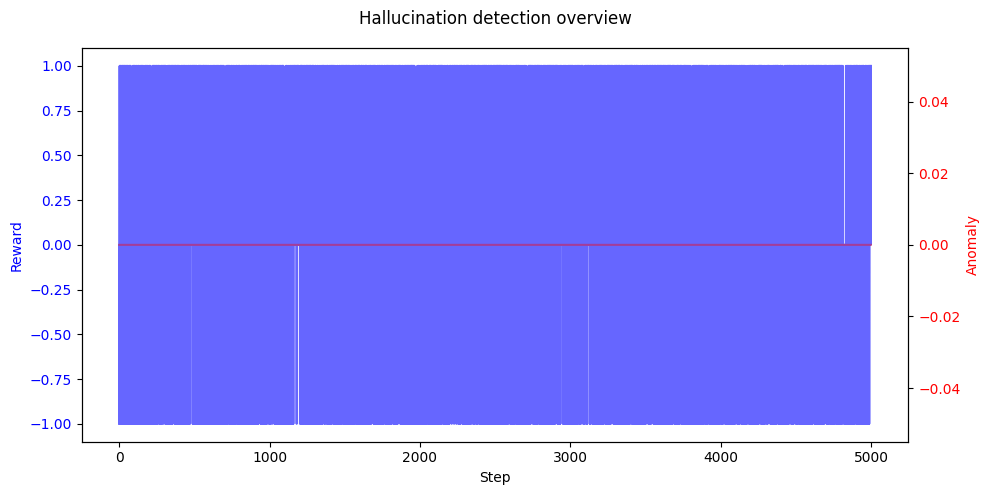

In [10]:
env_test = DummyVecEnv([lambda: Monitor(ForexEnv(df))])
results = detect_hallucinations(best_model, env_test, n_steps=5000, threshold=0.05)
env_test.close()

In [ ]:
import pandas as pd
from finrl import config, env_stock_trading  # exemple pour actions
from finrl.agent import DRLAgent
from stable_baselines3 import PPO

# 3. Préparation des données
# Supposons que df_mt5 est ton DataFrame avec une colonne 'close' et un index date
df = df_mt5.copy()
df = df.reset_index()  # selon ton format
df['date'] = pd.to_datetime(df['date'])
# Pour FinRL, il faut souvent colonnes: ['date','tic','open','high','low','close','volume']
# → Si tu as seulement ‘close’, on adapte :
df['tic'] = 'ID1'  # une seule “ticker”
df['open'] = df['close']
df['high'] = df['close']
df['low'] = df['close']
df['volume'] = 0

# 4. Split train / test
train_df = df[df['date'] < '2022‑01‑01'].copy()
test_df = df[df['date'] >= '2022‑01‑01'].copy()

# 5. Création de l’environnement
env_train, _ = env_stock_trading.make_env(df = train_df,
                                           stock_dim = 1,
                                           hmax = 1,
                                           initial_amount = 10000,
                                           transaction_cost_pct = 0.001,
                                           reward_scaling = 1e-4)

env_test, _ = env_stock_trading.make_env(df = test_df,
                                          stock_dim = 1,
                                          hmax = 1,
                                          initial_amount = 10000,
                                          transaction_cost_pct = 0.001,
                                          reward_scaling = 1e-4)

# 6. Création de l’agent
agent = DRLAgent(env = env_train)

# 7. Entraînement avec PPO
model_ppo = agent.get_model("ppo")
trained_ppo = agent.train_model(model=model_ppo,
                                tb_log_name="ppo_mytrader",
                                total_timesteps=10000)

# 8. Test / prédiction
df_account_value_ppo = agent.DRL_prediction(model=trained_ppo,
                                            environment = env_test)

print(df_account_value_ppo.tail())

ModuleNotFoundError: No module named 'finrl'